  Firstname Lastname Gender SPOS DSBDA     WT  DA
0        LA      Roy      M   85    88   90.0  92
1        SA    Dixit      F   90    90   94.0  95
2        AB   Danial      M   Na    na  100.0  80
3        DA   Kapoor      M   95    86  500.0  82
4        SA      Jha      F   Na    84   98.0  84

Missing Values
Firstname    0
Lastname     0
Gender       0
SPOS         2
DSBDA        4
WT           1
DA           1
dtype: int64


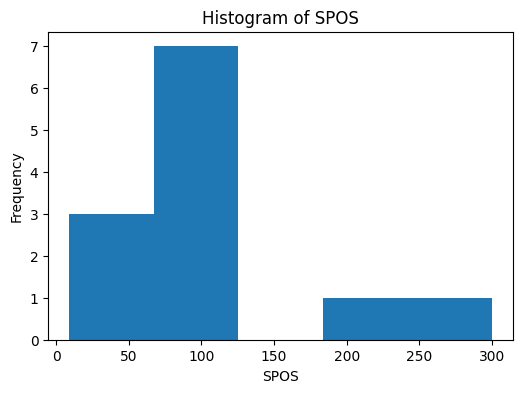

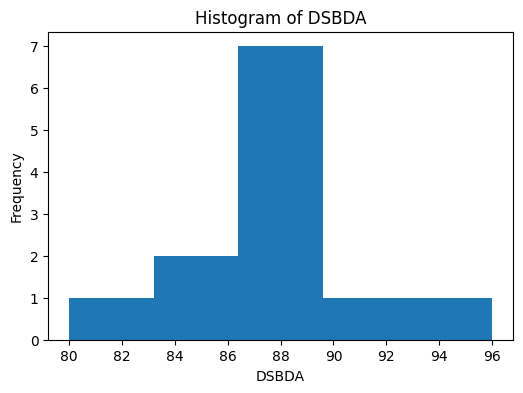

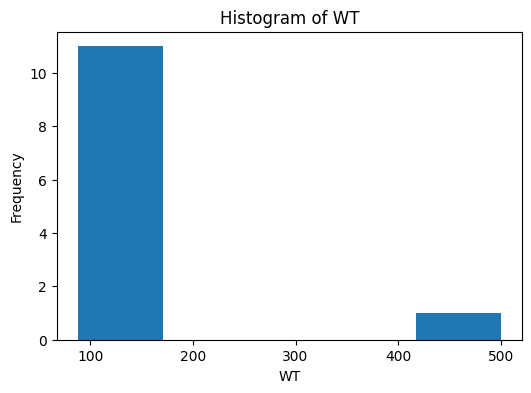

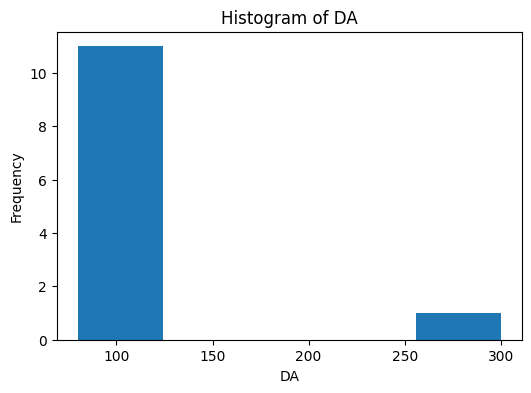

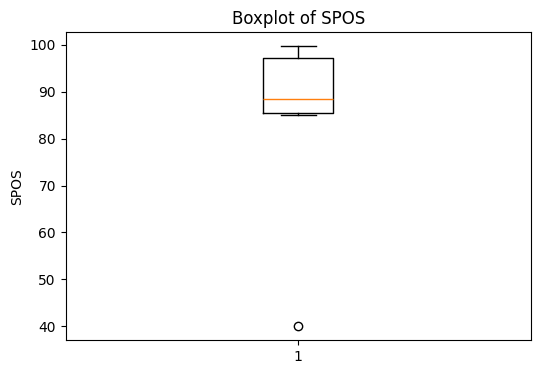

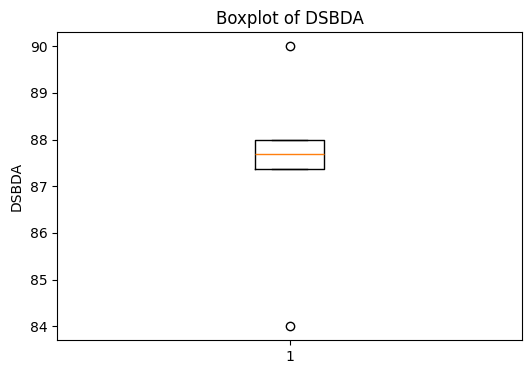

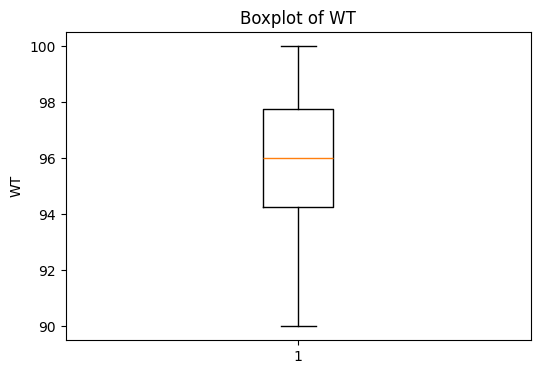

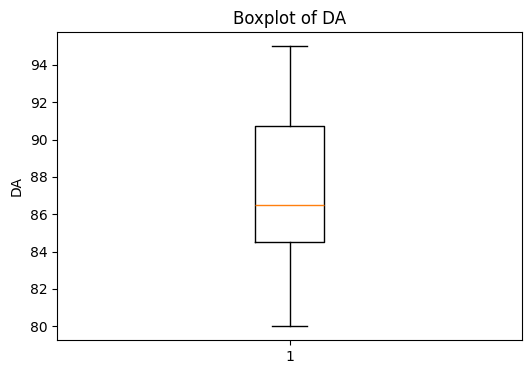

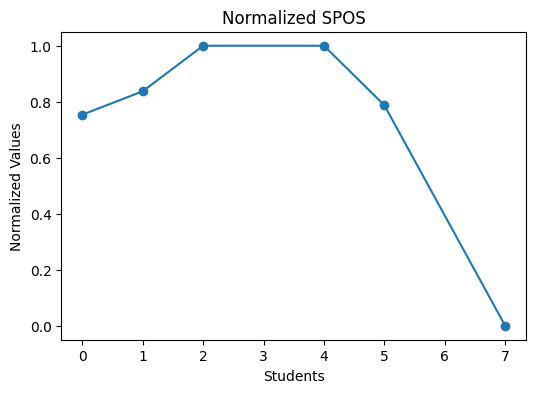

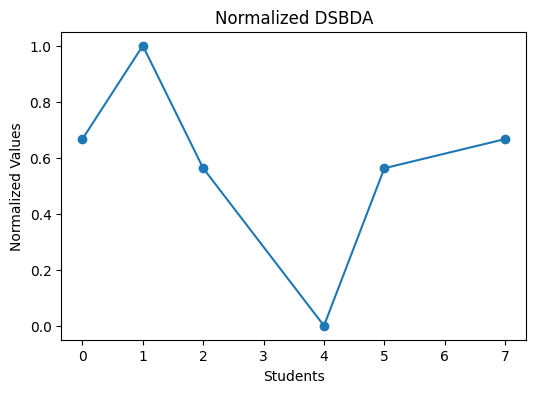

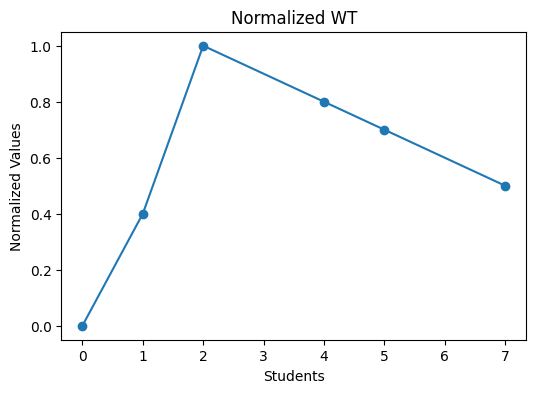

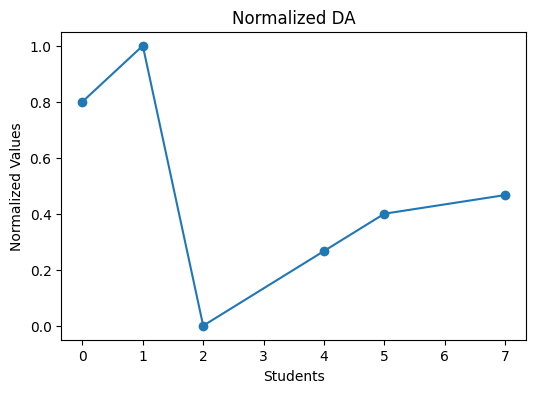


Final Dataset
  Firstname Lastname  Gender  SPOS   DSBDA     WT    DA  SPOS_Normalized  \
0        LA      Roy       0  85.0  88.000   90.0  92.0         0.753769   
1        SA    Dixit       1  90.0  90.000   94.0  95.0         0.837521   
2        AB   Danial       0  99.7  87.375  100.0  80.0         1.000000   
4        SA      Jha       1  99.7  84.000   98.0  84.0         1.000000   
5        WS   Thakur       1  87.0  87.375   97.0  86.0         0.787270   
7        JK   Khanna       1  40.0  88.000   95.0  87.0         0.000000   

   DSBDA_Normalized  WT_Normalized  DA_Normalized    Log_WT  
0          0.666667            0.0       0.800000  4.499810  
1          1.000000            0.4       1.000000  4.543295  
2          0.562500            1.0       0.000000  4.605170  
4          0.000000            0.8       0.266667  4.584967  
5          0.562500            0.7       0.400000  4.574711  
7          0.666667            0.5       0.466667  4.553877  

Statistical Summa

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    r"C:\Users\SANSKRUTI\OneDrive\Desktop\THIRD YEAR (TE)\DSBDA CODES\data2.csv"
)

# Display first rows
print(df.head())

# ---------------------------------------------------
# 1. Handling Missing Values and Inconsistencies
# ---------------------------------------------------

# Replace inconsistent values
df.replace(['Na', 'na'], np.nan, inplace=True)

# Convert columns into numeric
subjects = ['SPOS', 'DSBDA', 'WT', 'DA']

for sub in subjects:
    df[sub] = pd.to_numeric(df[sub], errors='coerce')

# Check missing values
print("\nMissing Values")
print(df.isnull().sum())

# Fill missing values using mean
for sub in subjects:
    df[sub] = df[sub].fillna(df[sub].mean())

# ---------------------------------------------------
# HISTOGRAMS
# ---------------------------------------------------
# Used to show distribution of marks

for sub in subjects:

    plt.figure(figsize=(6,4))

    plt.hist(df[sub], bins=5)

    plt.title(f"Histogram of {sub}")

    plt.xlabel(sub)

    plt.ylabel("Frequency")

    plt.show()

# ---------------------------------------------------
# 2. Outlier Detection using IQR Method
# ---------------------------------------------------

for sub in subjects:

    Q1 = df[sub].quantile(0.25)
    Q3 = df[sub].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Remove outliers
    df = df[
        (df[sub] >= lower) &
        (df[sub] <= upper)
    ]

# ---------------------------------------------------
# BOXPLOTS
# ---------------------------------------------------
# Used to detect outliers

for sub in subjects:

    plt.figure(figsize=(6,4))

    plt.boxplot(df[sub])

    plt.title(f"Boxplot of {sub}")

    plt.ylabel(sub)

    plt.show()

# ---------------------------------------------------
# 3. Data Transformation
# ---------------------------------------------------

# Normalization

for sub in subjects:

    df[sub + '_Normalized'] = (
        (df[sub] - df[sub].min()) /
        (df[sub].max() - df[sub].min())
    )

# Log Transformation on WT

df['Log_WT'] = np.log(df['WT'])

# Convert categorical variable into numeric

df['Gender'] = df['Gender'].map({
    'M': 0,
    'F': 1
})

# ---------------------------------------------------
# NORMALIZED GRAPHS
# ---------------------------------------------------
# Used to show transformed data

for sub in subjects:

    plt.figure(figsize=(6,4))

    plt.plot(
        df[sub + '_Normalized'],
        marker='o'
    )

    plt.title(f"Normalized {sub}")

    plt.xlabel("Students")

    plt.ylabel("Normalized Values")

    plt.show()

# ---------------------------------------------------
# Final Dataset
# ---------------------------------------------------

print("\nFinal Dataset")
print(df)

# ---------------------------------------------------
# Statistical Summary
# ---------------------------------------------------

print("\nStatistical Summary")
print(df.describe())